# Hidden Markov Model

In [1]:
from hmmlearn import hmm
import numpy as np

import pandas as pd

import glob
import scipy

import os

import matplotlib.pyplot as plt
import skimage

import regseq2
from tqdm.notebook import tqdm

import logging

logging.getLogger("hmmlearn").setLevel(logging.ERROR)

regseq2.viz.matplotlib_style()
color_dict = regseq2.viz.my_color_dict

In [2]:
def get_pixels(points, matplotlib_dpi=100):
    illustrator_dpi = 72
    
    return points/illustrator_dpi * matplotlib_dpi 

In [3]:
growth_conditions = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
growth_conditions.tail(5)

,Index,Condition,Description,Group
34,37,low phosphate,M9 Minimal Media with 0.5% Glucose to steady s...,Nutrient–mineral limitation
35,38,copper sulfate (2mM),M9 Minimal Media with 0.5% Glucose to steady s...,Metal & membrane stress
36,39,acetate,M9 Minimal Media with 0.5% Sodium Acetate,Carbon‐source
37,40,nitrate,M9 Minimal Media with 0.5% Glucose with 80mM P...,Osmotic & ionic stress
38,41,anaerobic + nitrate,M9 Minimal Media with 0.5% Glucose grown compl...,Anaerobic


In [4]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")
df_wt.head()

,genes,sequence,promoter,promoter_seq,fwd_primer,rev_primer1,rev_primer2,rev_primer3,upstream_re_site,downstream_re_site,name
0,"[""rspA"", ""rspB""]",ACCTGTAATTCCAAGCGTCTACTAGTTTTCATCTTTTGTCAACCAT...,rspAp,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,rspAp_0
1,"[""araA"", ""araB"", ""araD""]",ACCTGTAATTCCAAGCGTCTACTAGTTCCACATTGATTATTTGCAC...,araBp,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,araBp_0
2,"[""znuB"", ""znuC""]",ACCTGTAATTCCAAGCGTCTACTAGTGTGTTGCACCTCCCCAGAGA...,znuCp,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,znuCp_0
3,"[""xylA"", ""xylB""]",ACCTGTAATTCCAAGCGTCTACTAGTCCAGTTTCATCATTCCATTT...,xylAp,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,xylAp_0
4,"[""xylF"", ""xylG"", ""xylH"", ""xylR""]",ACCTGTAATTCCAAGCGTCTACTAGTAATTGCGCAACAAAAGTAAG...,xylFp,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,"(100, (1, 20))","(100, (231, 250))","(101, (193, 211))","(202, (212, 230))",SpeI,ApaI,xylFp_0


#

In [5]:
def hmm_fit(x, **kwargs):
    check = True
    i = 0
    while check:
        if i == 10:
            raise Exception("HMM not converging")
            
        X = x.reshape(-1, 1) 
        model = hmm.GaussianHMM(
            n_components=2,
            covariance_type='diag',
            n_iter=10000,
            init_params={'t': np.array([[0.9, 0.1], [0.1, 0.9]]), 'm': np.array([np.max(X), np.min(X)])},
            **kwargs
        )
        
        model.fit(X)
        state_sequence = model.predict(X)
        if not ((len(set(state_sequence[::2])) == 1) and (len(set(state_sequence[1::2])) == 1)):
            return model, state_sequence, model.score(X)
            check = False
        i += 1

In [9]:
def run_hmm(prom, gc, rep, sigma=2, ax=None, fig=None, **kwargs):
    
    # Get data
    df = pd.read_csv(f"../../data/footprints/{gc}-{rep}_footprints.csv")
    x = df.loc[df.promoter == prom, "mut_info"].values
    # smooth footprint
    x = scipy.ndimage.gaussian_filter1d(x, sigma)
    # normalize footprint
    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x))

    
    ident_arr = []
    models = []
    models_rev = []
    scores = []
    scores_rev = []
    for i in range(50):
        model, state_sequence, score = hmm_fit(x_scaled, **kwargs)
        model_rev, state_sequence_rev, score_rev = hmm_fit(x_scaled[::-1], **kwargs)
        models.append((model, state_sequence))
        models_rev.append((model_rev, state_sequence_rev))
        scores.append(score)
        scores_rev.append(score_rev)

    
    best_model_ind = np.argmax(scores)
    model, state_sequence= models[best_model_ind]

    best_model_ind_rev = np.argmax(scores_rev)
    model_rev, state_sequence_rev = models_rev[best_model_ind_rev]

    if ax is None:
        fig, ax = plt.subplots(1, 3, figsize=(14, 2))
    
    if model.means_[0][0] > model.means_[1][0]:
        ax[0].bar(np.arange(-115 ,45)*[1-state_sequence][0], x*[1-state_sequence][0], width=1, color=color_dict['orange1'])
        ax[0].bar(np.arange(-115 ,45)*[state_sequence][0], x*[state_sequence][0], width=1, color=color_dict['blue1'])
    else:
        ax[0].bar(np.arange(-115 ,45)*[state_sequence][0], x*[state_sequence][0], width=1, color=color_dict['orange1'])
        ax[0].bar(np.arange(-115 ,45)*[1-state_sequence][0], x*[1-state_sequence][0], width=1, color=color_dict['blue1'])
    ax[0].set_axisbelow(True)
    ax[0].grid(True, linewidth=0.5, color="white", linestyle="--")

    if model_rev.means_[0][0] > model_rev.means_[1][0]:
        ax[1].bar(np.arange(-115 ,45)*[1-state_sequence_rev[::-1]][0], x*[1-state_sequence_rev[::-1]][0], width=1, color=color_dict['orange1'])
        ax[1].bar(np.arange(-115 ,45)*[state_sequence_rev[::-1]][0], x*[state_sequence_rev[::-1]][0], width=1, color=color_dict['blue1'])
    else:
        ax[1].bar(np.arange(-115 ,45)*[state_sequence_rev[::-1]][0], x*[state_sequence_rev[::-1]][0], width=1, color=color_dict['orange1'])
        ax[1].bar(np.arange(-115 ,45)*[1-state_sequence_rev[::-1]][0], x*[1-state_sequence_rev[::-1]][0], width=1, color=color_dict['blue1'])
    ax[1].set_axisbelow(True)
    ax[1].grid(True, linewidth=0.5, color="white", linestyle="--")
    ax[1].set_yticks([])
    ax[1].sharey(ax[0])
    #ax[1].set_yticks([])
    
    x_norm = np.linspace(- 4*sigma, 4*sigma, 100)
    y_norm = scipy.stats.norm.pdf(x_norm, 0, sigma)
    ax[2].plot(x_norm, y_norm, '--', color="gray")
    ax[2].grid(True, linewidth=0.5, color="white", linestyle="--")
  
    return fig, ax


In [ ]:
def compare_hmm_conditions(prom, gc, rep, save=False, **kwargs):
    if save:
        regseq2.viz.paper_params()
    fig, ax = plt.subplots(3,3, figsize=(8, 3), constrained_layout=True, gridspec_kw={'width_ratios': [5, 5, 1]})
    run_hmm(prom, gc, rep, sigma=0.5, ax=ax[0], fig=fig, **kwargs)
    run_hmm(prom, gc, rep, sigma=2, ax=ax[1], fig=fig, **kwargs)
    run_hmm(prom, gc, rep, sigma=4, ax=ax[2], fig=fig, **kwargs)
    ax[0, 0].set_title("forward HMM")
    ax[0, 1].set_title("reverse HMM")
    ax[0, 2].set_title("smoothing\nkernel")
    
    ax[0, 2].sharex(ax[2, 2])
    ax[1, 2].sharex(ax[2, 2])
    for _ax in fig.get_axes():
        if _ax != ax[0, 2] and _ax != ax[1, 2] and _ax != ax[2, 2]:
            _ax.label_outer()
    
    fig.supxlabel('position relative to TSS', x=5/11)
    fig.supylabel('mutual information [bits]')
    if save:
        
        width_pts = 240
        height_pts = 140
        dpi = 100
        
        # Calculate figsize in inches
        width_in = get_pixels(width_pts) / dpi
        height_in = get_pixels(height_pts) / dpi
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.set_figwidth(width_in)
        fig.set_figheight(height_in)
        fig.set_dpi(dpi)
        fig.savefig(f"{prom}_{gc}_{rep}_hmm_test.pdf")
    else:
        regseq2.viz.notebook_params()
    return fig, ax

### tisBp

/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_49613/116453246.py:27: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0, right=1, top=1, bottom=0)


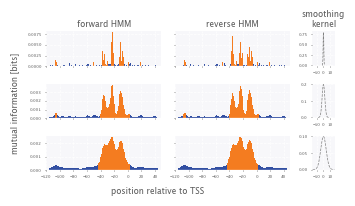

In [13]:
prom = "tisBp"
gc = 1
rep = 1
fig, ax = compare_hmm_conditions(prom, gc, rep, save=True)


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_49613/116453246.py:27: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0, right=1, top=1, bottom=0)


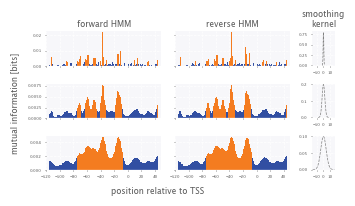

In [12]:
prom = "araBp"
gc = 3
rep = 1
fig, ax = compare_hmm_conditions(prom, gc, rep, save=True)


### cusC

Model is not converging.  Current: 165.29227518933038 is not greater than 165.30076805449457. Delta is -0.008492865164186014
Model is not converging.  Current: 165.29508136496787 is not greater than 165.2999999631868. Delta is -0.004918598218921488
Model is not converging.  Current: 165.29741196962277 is not greater than 165.3048587274976. Delta is -0.007446757874816967
Model is not converging.  Current: 165.28562230082233 is not greater than 165.2969524262341. Delta is -0.011330125411774361
Model is not converging.  Current: 165.29240040388777 is not greater than 165.30201830758517. Delta is -0.009617903697403563
Model is not converging.  Current: 165.3063354455588 is not greater than 165.30741940212954. Delta is -0.0010839565707385646
Model is not converging.  Current: 165.28138091796689 is not greater than 165.2873404530455. Delta is -0.005959535078602585
Model is not converging.  Current: 165.29671311475846 is not greater than 165.29943788116307. Delta is -0.0027247664046115005
Mod

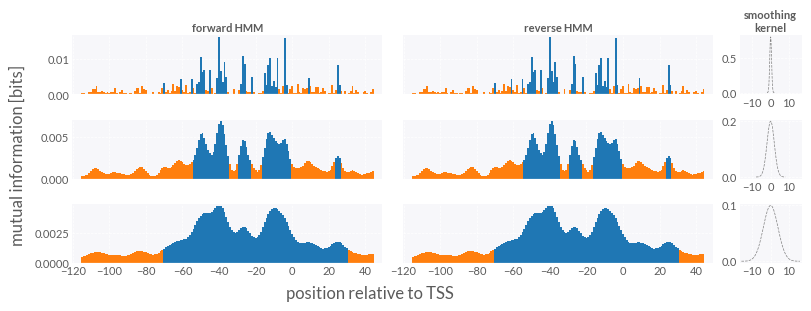

In [19]:
prom = "cusCp"
gc = 38
rep = 1
compare_hmm_conditions(prom, gc, rep, verbose=False)

Model is not converging.  Current: 131.26107175145418 is not greater than 131.2611462787278. Delta is -7.452727362533551e-05
Model is not converging.  Current: 147.07503032274266 is not greater than 147.075117576363. Delta is -8.725362033601414e-05
Model is not converging.  Current: 131.26034927745113 is not greater than 131.2608901563528. Delta is -0.0005408789016598803
Model is not converging.  Current: 131.26068977154176 is not greater than 131.2612023150921. Delta is -0.0005125435503430253
Model is not converging.  Current: 146.99449613643216 is not greater than 147.0302226029. Delta is -0.035726466467849605
Model is not converging.  Current: 119.3097134276212 is not greater than 119.32020035571801. Delta is -0.010486928096810288
Model is not converging.  Current: 119.31590163083519 is not greater than 119.317255046272. Delta is -0.0013534154368102236
Model is not converging.  Current: 119.31602391997808 is not greater than 119.31836871160064. Delta is -0.00234479162256207
Model is

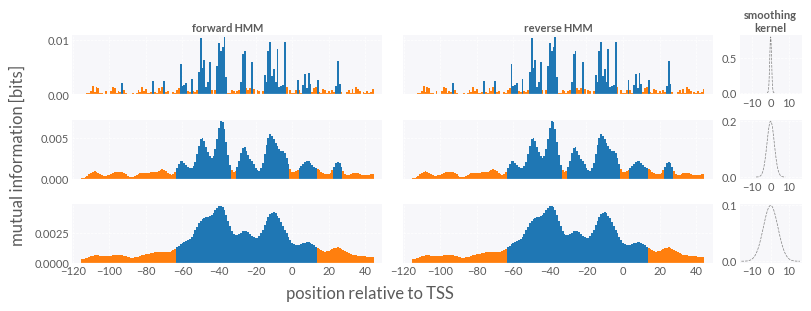

In [20]:
prom = "cusCp"
gc = 38
rep = 3
compare_hmm_conditions(prom, gc, rep)

### araBp

Model is not converging.  Current: 214.83535627355818 is not greater than 214.83633943377524. Delta is -0.0009831602170606857
Model is not converging.  Current: 216.37796116755405 is not greater than 216.3877142806731. Delta is -0.009753113119046475
Model is not converging.  Current: 214.8573686684889 is not greater than 214.8602076013185. Delta is -0.002838932829604346
Model is not converging.  Current: 216.39447938100727 is not greater than 216.39517676876054. Delta is -0.0006973877532630013
Model is not converging.  Current: 214.91302156910862 is not greater than 214.91748827804847. Delta is -0.004466708939844466
Model is not converging.  Current: 216.39126619026197 is not greater than 216.396883427283. Delta is -0.005617237021027677
Model is not converging.  Current: 216.39431304318276 is not greater than 216.39534594214263. Delta is -0.0010328989598633598
Model is not converging.  Current: 214.93568401030828 is not greater than 214.93999457118534. Delta is -0.004310560877058833
Mo

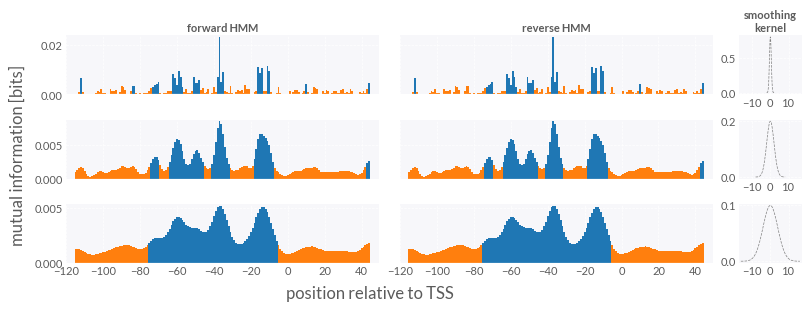

In [21]:
prom = "araBp"
gc = 3
rep = 2
compare_hmm_conditions(prom, gc, rep)

### rspAp

Model is not converging.  Current: 97.79627810469074 is not greater than 97.80252023699963. Delta is -0.006242132308884152
Model is not converging.  Current: 98.6168684747979 is not greater than 98.63793834971504. Delta is -0.021069874917145626
Model is not converging.  Current: 97.78161991371687 is not greater than 97.78206779159851. Delta is -0.0004478778816405793
Model is not converging.  Current: 92.13521071100644 is not greater than 92.13902473969449. Delta is -0.0038140286880548047


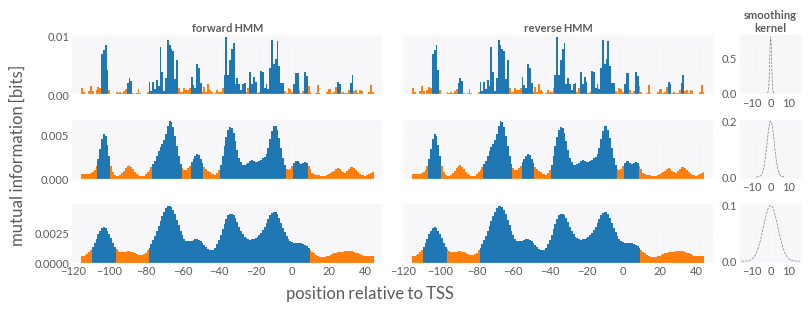

In [22]:
prom = "rspAp"
gc = 2
rep = 1

compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 168.78304577863818 is not greater than 168.84244428803385. Delta is -0.05939850939566327
Model is not converging.  Current: 168.72218628260563 is not greater than 168.75282902863503. Delta is -0.030642746029400314
Model is not converging.  Current: 168.66244047089498 is not greater than 168.7013200123064. Delta is -0.03887954141143268
Model is not converging.  Current: 168.81032497586955 is not greater than 168.86790440181377. Delta is -0.05757942594422616
Model is not converging.  Current: 168.89331345178996 is not greater than 168.9406006306541. Delta is -0.04728717886413847
Model is not converging.  Current: 168.8270228478098 is not greater than 168.87915969710824. Delta is -0.052136849298449306
Model is not converging.  Current: 168.67961885189365 is not greater than 168.71302356353658. Delta is -0.03340471164293035
Model is not converging.  Current: 168.42386946730338 is not greater than 168.44664895299098. Delta is -0.022779485687607348
Model is

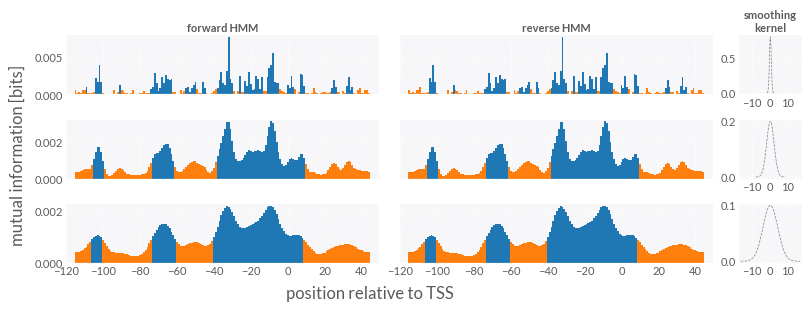

In [23]:
prom = "rspAp"
gc = 1
rep = 1

compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 193.77628899006442 is not greater than 193.79032070343223. Delta is -0.014031713367813836
Model is not converging.  Current: 193.90466136173032 is not greater than 193.90843131014987. Delta is -0.003769948419545699
Model is not converging.  Current: 194.6972184224921 is not greater than 194.70563447376367. Delta is -0.00841605127155276
Model is not converging.  Current: 193.77820057927727 is not greater than 193.7869501323846. Delta is -0.008749553107321617
Model is not converging.  Current: 193.89034369421543 is not greater than 193.91715550585923. Delta is -0.02681181164379609
Model is not converging.  Current: 193.9104605704671 is not greater than 193.91749634025555. Delta is -0.007035769788444668
Model is not converging.  Current: 194.7463739073271 is not greater than 194.77438301776226. Delta is -0.028009110435164075
Model is not converging.  Current: 193.9085814695022 is not greater than 193.9191993348341. Delta is -0.010617865331909115
Model is

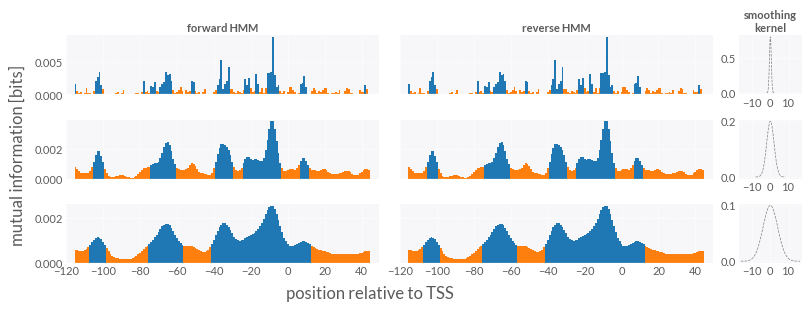

In [24]:
prom = "rspAp"
gc = 1
rep = 2

compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 82.84575265031208 is not greater than 82.84831999069019. Delta is -0.002567340378107019
Model is not converging.  Current: 82.86029341943002 is not greater than 82.86720104504096. Delta is -0.006907625610935497
Model is not converging.  Current: 82.85558889247426 is not greater than 82.86707134910847. Delta is -0.011482456634212213


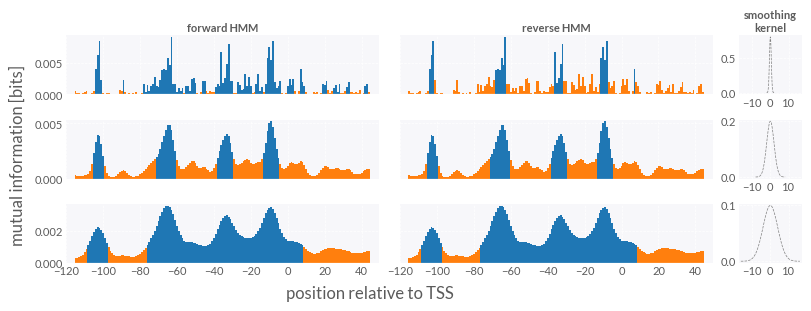

In [25]:
prom = "rspAp"
gc = 3
rep = 2

compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 221.4639456624221 is not greater than 221.46628547440983. Delta is -0.0023398119877242607
Model is not converging.  Current: 221.78206951350887 is not greater than 221.84505569891002. Delta is -0.06298618540114376
Model is not converging.  Current: 221.8544208120595 is not greater than 221.94236358197017. Delta is -0.08794276991068273
Model is not converging.  Current: 144.81456448427332 is not greater than 144.8200901658993. Delta is -0.00552568162598277
Model is not converging.  Current: 144.81534541532434 is not greater than 144.82020618711826. Delta is -0.004860771793914864
Model is not converging.  Current: 144.79268247561666 is not greater than 144.79829264349044. Delta is -0.005610167873783212
Model is not converging.  Current: 144.7920236907765 is not greater than 144.79782558566518. Delta is -0.005801894888691095
Model is not converging.  Current: 144.81542930538285 is not greater than 144.82021612018167. Delta is -0.004786814798819705
Model 

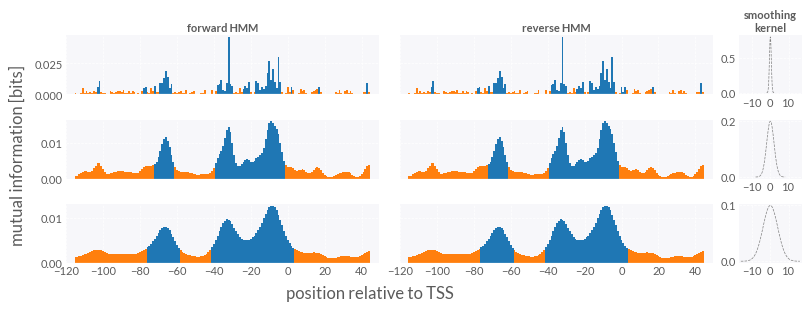

In [26]:
prom = "rspAp"
gc = 7
rep = 1

compare_hmm_conditions(prom, gc, rep)

### yjbJ

Model is not converging.  Current: 281.63543885424775 is not greater than 281.66581928717255. Delta is -0.03038043292480097
Model is not converging.  Current: 281.6113672469951 is not greater than 281.6302881995638. Delta is -0.018920952568691973
Model is not converging.  Current: 281.6291282276763 is not greater than 281.70493934399076. Delta is -0.07581111631446902
Model is not converging.  Current: 281.7305592468383 is not greater than 281.91836517309054. Delta is -0.18780592625222425
Model is not converging.  Current: 281.6301962450132 is not greater than 281.7256288606794. Delta is -0.09543261566619776
Model is not converging.  Current: 281.6328093320088 is not greater than 281.7223842289556. Delta is -0.08957489694682863
Model is not converging.  Current: 281.6150061915876 is not greater than 281.6462291733906. Delta is -0.031222981803011862
Model is not converging.  Current: 281.658124537088 is not greater than 281.81450426935135. Delta is -0.15637973226336044
Model is not conve

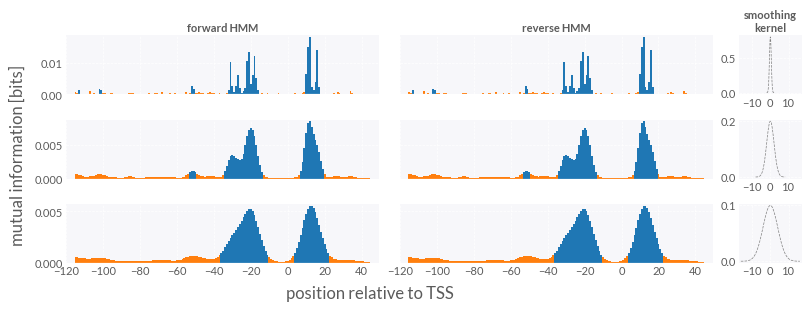

In [27]:
prom = "yjbJ_predicted"
gc = 36
rep = 1

compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 230.73920825054407 is not greater than 230.78610759594343. Delta is -0.046899345399367576
Model is not converging.  Current: 231.00748350433778 is not greater than 231.02073403439428. Delta is -0.01325053005649579
Model is not converging.  Current: 230.93286821151767 is not greater than 230.94715324648683. Delta is -0.01428503496916278
Model is not converging.  Current: 230.65621554642826 is not greater than 230.6688319546659. Delta is -0.012616408237647647
Model is not converging.  Current: 230.74614324038774 is not greater than 230.7830901423598. Delta is -0.03694690197207251
Model is not converging.  Current: 230.73758838937036 is not greater than 230.75338362127513. Delta is -0.015795231904775164
Model is not converging.  Current: 221.19278637697124 is not greater than 221.23392266698994. Delta is -0.041136290018698674
Model is not converging.  Current: 208.32298780250144 is not greater than 208.33955367704817. Delta is -0.01656587454672831
Model 

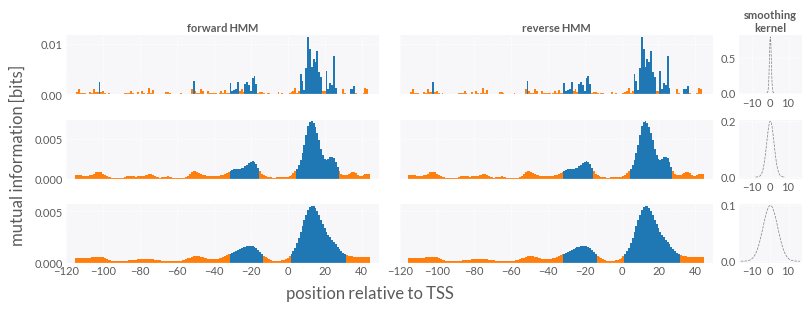

In [28]:
prom = "yjbJ_predicted"
gc = 8
rep = 1

compare_hmm_conditions(prom, gc, rep)

### yadI

Model is not converging.  Current: 185.4439302967173 is not greater than 185.4445569940578. Delta is -0.0006266973404933651
Model is not converging.  Current: 185.4545608864027 is not greater than 185.45867289392476. Delta is -0.004112007522053318
Model is not converging.  Current: 185.44309480226244 is not greater than 185.44574198160532. Delta is -0.0026471793428868295
Model is not converging.  Current: 185.43694513633216 is not greater than 185.43809480415874. Delta is -0.0011496678265814353
Model is not converging.  Current: 185.4420810147995 is not greater than 185.4443618286625. Delta is -0.002280813862995501
Model is not converging.  Current: 185.42138496614498 is not greater than 185.42251407609157. Delta is -0.001129109946589324
Model is not converging.  Current: 185.4431002512629 is not greater than 185.44354320840088. Delta is -0.00044295713797737335
Model is not converging.  Current: 154.58940909703347 is not greater than 154.60727640494898. Delta is -0.017867307915508945
M

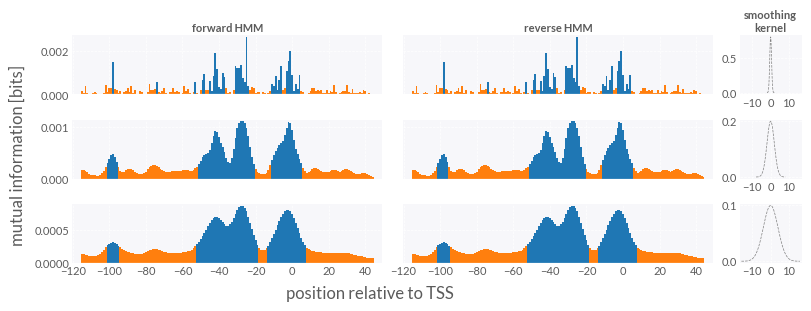

In [29]:
prom = "yadI_predicted"
gc = 13
rep = 1

compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 125.20138641897127 is not greater than 125.2098893093212. Delta is -0.00850289034993068
Model is not converging.  Current: 124.7130765750503 is not greater than 124.71608801664827. Delta is -0.0030114415979767273
Model is not converging.  Current: 124.70814821954038 is not greater than 124.71248704351176. Delta is -0.004338823971380634
Model is not converging.  Current: 125.22225816315023 is not greater than 125.23268566647604. Delta is -0.010427503325814769
Model is not converging.  Current: 125.18010178431824 is not greater than 125.1881387454804. Delta is -0.008036961162162015
Model is not converging.  Current: 124.63458048580722 is not greater than 124.63584326387557. Delta is -0.001262778068351622
Model is not converging.  Current: 124.79431781783147 is not greater than 124.7963859650686. Delta is -0.0020681472371251175
Model is not converging.  Current: 124.75879169380764 is not greater than 124.76029319771582. Delta is -0.0015015039081873738
Mo

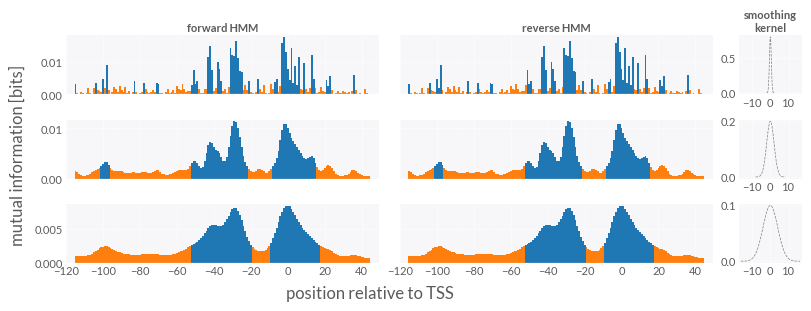

In [30]:
prom = "yadI_predicted"
gc = 8
rep = 1
compare_hmm_conditions(prom, gc, rep)

### yadE

Model is not converging.  Current: 198.9426776585522 is not greater than 198.9484978395219. Delta is -0.005820180969692501
Model is not converging.  Current: 198.9236444876204 is not greater than 198.94193878849754. Delta is -0.018294300877130354
Model is not converging.  Current: 198.87440669245413 is not greater than 198.8804107428147. Delta is -0.006004050360559177
Model is not converging.  Current: 198.94141673501784 is not greater than 198.94940589767128. Delta is -0.007989162653444737
Model is not converging.  Current: 198.92539865646305 is not greater than 198.94254352963762. Delta is -0.017144873174572695
Model is not converging.  Current: 198.93786393994125 is not greater than 198.95060352732168. Delta is -0.012739587380423245
Model is not converging.  Current: 198.94174352446137 is not greater than 198.94915723156748. Delta is -0.007413707106110223
Model is not converging.  Current: 198.9231110457155 is not greater than 198.94167926685157. Delta is -0.018568221136064267
Model

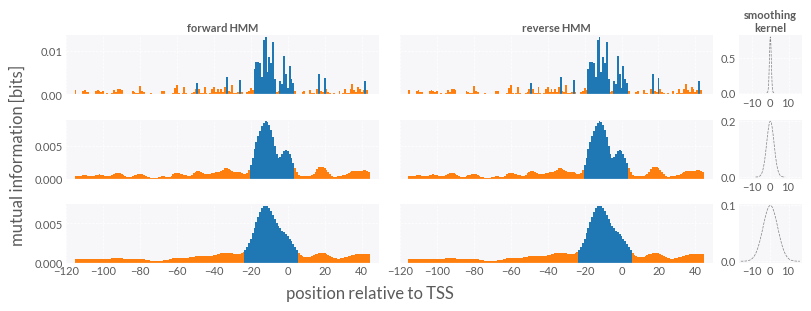

In [31]:
prom = "yadE_predicted"
gc = 8
rep = 1
compare_hmm_conditions(prom, gc, rep)

### yagB

Model is not converging.  Current: 219.50269577739462 is not greater than 219.50918898840445. Delta is -0.0064932110098254725
Model is not converging.  Current: 219.50182527227756 is not greater than 219.50695441468181. Delta is -0.005129142404257436
Model is not converging.  Current: 219.5042161940351 is not greater than 219.50990122746097. Delta is -0.0056850334258626845
Model is not converging.  Current: 219.50048750602397 is not greater than 219.50086371200058. Delta is -0.0003762059766074799
Model is not converging.  Current: 219.50472096799905 is not greater than 219.50705730704522. Delta is -0.002336339046166813
Model is not converging.  Current: 219.50272882557252 is not greater than 219.5091355690533. Delta is -0.006406743480795285
Model is not converging.  Current: 219.50445437250778 is not greater than 219.50849819037796. Delta is -0.004043817870183375
Model is not converging.  Current: 219.50251877317058 is not greater than 219.50394143317206. Delta is -0.001422660001480835

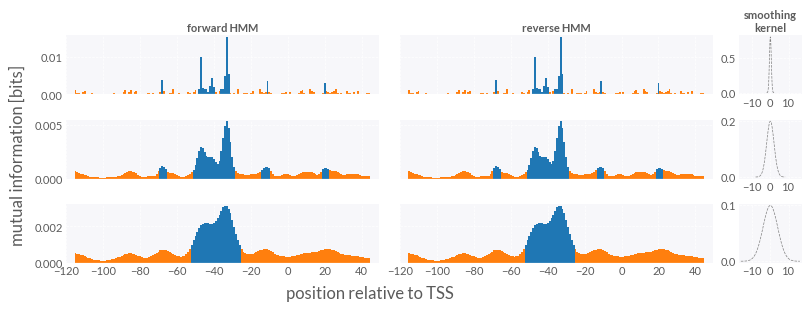

In [32]:
prom = "yagB_insX_yagA_predicted"
gc = 8
rep = 1
compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 244.40795022695232 is not greater than 244.42362842786247. Delta is -0.015678200910144824
Model is not converging.  Current: 244.68805347247095 is not greater than 244.73659222253502. Delta is -0.04853875006406838
Model is not converging.  Current: 244.7722183951031 is not greater than 244.86178844173372. Delta is -0.08957004663062662
Model is not converging.  Current: 244.61156238672328 is not greater than 244.63697954366648. Delta is -0.02541715694320601
Model is not converging.  Current: 244.69766634975161 is not greater than 244.82637523242514. Delta is -0.12870888267352143
Model is not converging.  Current: 244.92610990540575 is not greater than 244.98442216913082. Delta is -0.058312263725071034
Model is not converging.  Current: 244.78266874729644 is not greater than 244.8954232173755. Delta is -0.11275447007906791
Model is not converging.  Current: 244.63010964971994 is not greater than 244.74492244040354. Delta is -0.11481279068360095
Model is

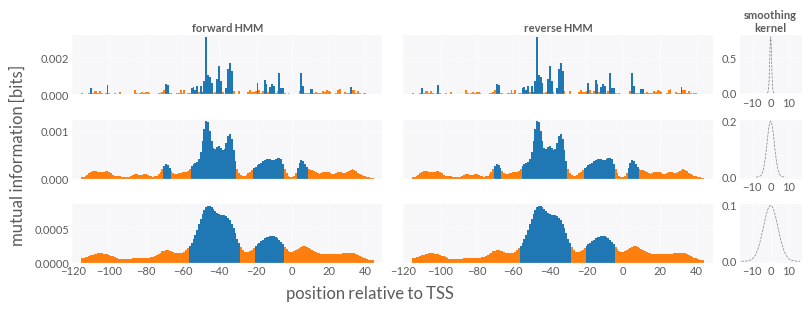

In [33]:
prom = "yagB_insX_yagA_predicted"
gc = 36
rep = 1
compare_hmm_conditions(prom, gc, rep)

### yqjE

Model is not converging.  Current: 218.25847797152335 is not greater than 218.26036232556967. Delta is -0.001884354046325143
Model is not converging.  Current: 218.3134808896242 is not greater than 218.3144844797707. Delta is -0.0010035901464959807
Model is not converging.  Current: 218.19809528731736 is not greater than 218.20377317648956. Delta is -0.0056778891722046865
Model is not converging.  Current: 218.4809386778418 is not greater than 218.48300251666384. Delta is -0.002063838822039088
Model is not converging.  Current: 218.48017088266263 is not greater than 218.48075414739478. Delta is -0.0005832647321426521
Model is not converging.  Current: 218.4818532775009 is not greater than 218.48584984180468. Delta is -0.00399656430377604
Model is not converging.  Current: 218.4799530034393 is not greater than 218.48172061394925. Delta is -0.0017676105099440065
Model is not converging.  Current: 218.482364507402 is not greater than 218.48556268323324. Delta is -0.0031981758312440434
Mod

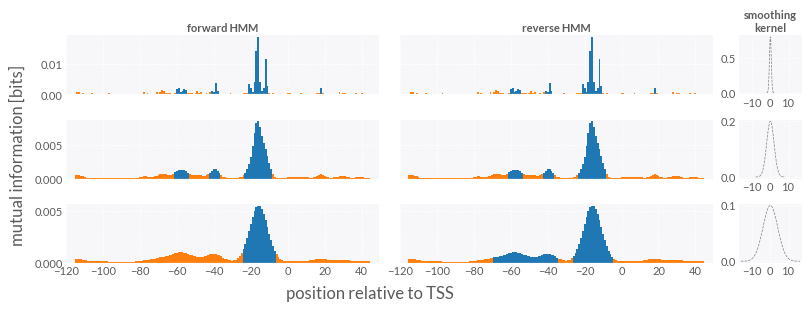

In [34]:
prom = "yqjE_yqjK_yqjD_yqjC_predicted"
gc = 36
rep = 1
compare_hmm_conditions(prom, gc, rep)

Model is not converging.  Current: 292.82662558347374 is not greater than 292.9554932259353. Delta is -0.12886764246155735
Model is not converging.  Current: 292.79724739062743 is not greater than 292.86620730503915. Delta is -0.068959914411721
Model is not converging.  Current: 292.8376800152921 is not greater than 292.9285748438514. Delta is -0.09089482855927145
Model is not converging.  Current: 292.77479938758614 is not greater than 292.82626025568095. Delta is -0.05146086809480721
Model is not converging.  Current: 292.7921194667725 is not greater than 292.8603598501457. Delta is -0.06824038337322236
Model is not converging.  Current: 292.7814551722371 is not greater than 292.7903507847695. Delta is -0.0088956125323989
Model is not converging.  Current: 292.83083871956615 is not greater than 292.9019399213727. Delta is -0.07110120180652757
Model is not converging.  Current: 292.87605603628623 is not greater than 292.97661348715263. Delta is -0.100557450866404
Model is not convergi

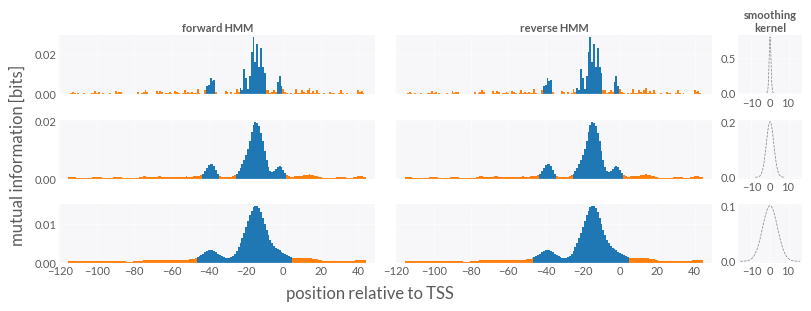

In [35]:
prom = "yqjE_yqjK_yqjD_yqjC_predicted"
gc = 7
rep = 1
compare_hmm_conditions(prom, gc, rep)

### TSS1414

Model is not converging.  Current: 227.12641809617836 is not greater than 227.1581337148323. Delta is -0.031715618653947786
Model is not converging.  Current: 227.0587464187036 is not greater than 227.07375396244373. Delta is -0.015007543740125584
Model is not converging.  Current: 227.15145691524242 is not greater than 227.18148146269434. Delta is -0.03002454745191585
Model is not converging.  Current: 227.0861794544518 is not greater than 227.09813085469665. Delta is -0.01195140024483976
Model is not converging.  Current: 227.14987394303108 is not greater than 227.1787137716515. Delta is -0.028839828620419894
Model is not converging.  Current: 227.12377496306453 is not greater than 227.1562936263365. Delta is -0.03251866327195785
Model is not converging.  Current: 227.1532702983042 is not greater than 227.17890774963263. Delta is -0.025637451328435645
Model is not converging.  Current: 227.0454494311994 is not greater than 227.04883361995235. Delta is -0.0033841887529604264
Model is 

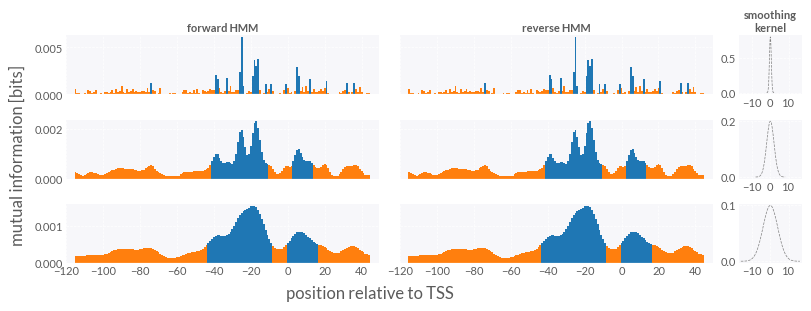

In [36]:
prom = "TSS_1414_storz_regulondb"
gc = 3
rep = 1
compare_hmm_conditions(prom, gc, rep)

### ybaY

Model is not converging.  Current: 190.31137903226173 is not greater than 190.32721403806363. Delta is -0.01583500580190389
Model is not converging.  Current: 190.30726043001522 is not greater than 190.31436572606583. Delta is -0.007105296050610832
Model is not converging.  Current: 190.31526304036552 is not greater than 190.33136186615252. Delta is -0.016098825786997395
Model is not converging.  Current: 190.3053397960896 is not greater than 190.31298481857783. Delta is -0.007645022488219411
Model is not converging.  Current: 190.3125407305904 is not greater than 190.3311750973549. Delta is -0.01863436676450192
Model is not converging.  Current: 190.3120285055161 is not greater than 190.32953092480335. Delta is -0.017502419287239945
Model is not converging.  Current: 190.3182466202464 is not greater than 190.33196891074047. Delta is -0.013722290494058598
Model is not converging.  Current: 190.32214951989076 is not greater than 190.32218882184333. Delta is -3.930195256884872e-05
Model 

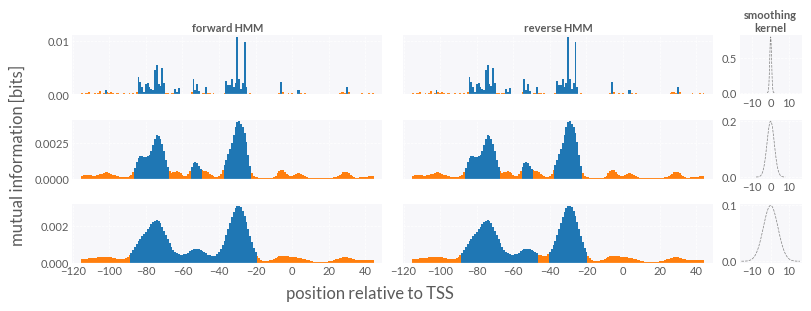

In [37]:
prom = "ybaY_predicted"
gc = 36
rep = 1
compare_hmm_conditions(prom, gc, rep)

### acrZp

Model is not converging.  Current: 136.62744065972805 is not greater than 136.63865093697848. Delta is -0.011210277250427225
Model is not converging.  Current: 96.7531242910984 is not greater than 96.75407153138342. Delta is -0.0009472402850150274


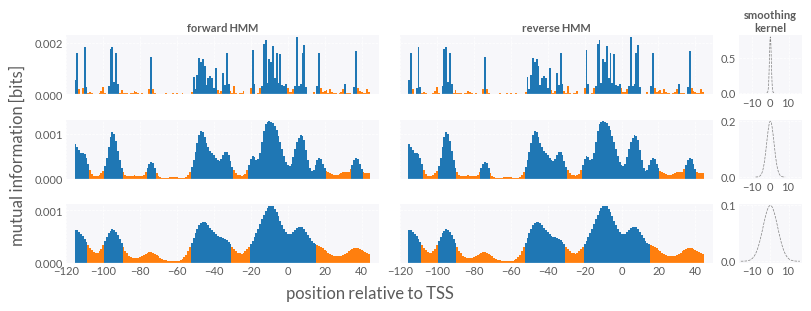

In [38]:
prom = "acrZp"
gc = 24
rep = 2
compare_hmm_conditions(prom, gc, rep)

In [9]:
def run_hmm_2(x, sigma=2, **kwargs):
    # smooth footprint
    x = scipy.ndimage.gaussian_filter1d(x, sigma)
    # normalize footprint
    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x))

    
    ident_arr = []
    models = []
    scores = []
    for i in range(50):
        model, state_sequence, score = hmm_fit(x_scaled, **kwargs)
        models.append((model, state_sequence))
        scores.append(score)
    
    best_model_ind = np.argmax(scores)
    model, state_sequence = models[best_model_ind]

    if np.sum(x * state_sequence)/np.sum(state_sequence) > np.sum(x * (1 - state_sequence))/np.sum((1 - state_sequence)):
        return state_sequence
    else:
        return 1 - state_sequence
    

# Run on all data

In [10]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
df_gc.head(5)

,Index,Condition,Description,Group
0,1,Glucose,M9 Minimal Media with 0.5% Glucose,Carbon‐source
1,2,Xylose,M9 Minimal Media with 0.5% Xylose,Carbon‐source
2,3,Arabinose,M9 Minimal Media with 0.5% Arabinose,Carbon‐source
3,4,Galactose,M9 Minimal Media with 0.23% Galactose,Carbon‐source
4,5,Sodium Salicytate,M9 Minimal Media with 0.5% Glucose and 2.5mM S...,Small-molecule inducers


In [16]:
df_triage = pd.read_csv("files/triaging.csv")
df_triage = df_triage[df_triage.classification > 0]
df_triage.head()

,promoter,gc,rep,cv,cv_smooth,entropy,entropy_smooth,classification
0,araBp,29,2,5.105271,1.938526,4.787686,6.292157,1
1,mglBp,9,2,4.801802,1.775373,4.960044,6.371064,1
2,araBp,41,2,4.614532,1.676568,5.100020,6.498608,1
3,araBp,9,2,4.604240,1.720245,5.004471,6.446054,1
4,araBp,13,2,4.586132,1.671479,5.070243,6.494205,1


In [17]:
df_triage[df_triage['gc'] == 34]

,promoter,gc,rep,cv,cv_smooth,entropy,entropy_smooth,classification
8,araBp,34,1,4.469008,1.614801,5.028547,6.521698,1
61,ihfAp4,34,2,3.576803,2.083192,4.774407,5.836751,2
62,araBp,34,2,3.576739,1.342544,5.458216,6.698408,1
68,mglBp,34,1,3.542623,1.313735,5.336970,6.661267,1
91,ihfAp4,34,1,3.485350,2.025300,4.813180,5.876151,2
...,...,...,...,...,...,...,...,...
6432,crpp1,34,2,1.487577,0.778546,6.174014,6.987129,2
6853,crpp1,34,1,1.447451,0.838508,6.201708,6.936923,2
6894,ykgRp,34,2,1.444470,0.793031,6.212944,6.932053,2
7192,ykgRp,34,1,1.418515,0.750563,6.277011,6.959099,2


In [18]:
df_triage[(df_triage['promoter'] == 'dinQp') & ((df_triage['gc'] == 28))]

,promoter,gc,rep,cv,cv_smooth,entropy,entropy_smooth,classification
4255,dinQp,28,1,1.754888,1.066488,5.945795,6.731980,2
5191,dinQp,28,2,1.628251,0.940961,6.056238,6.865266,2


In [19]:
prom_list = []
gc_list = []
rep_list = []
state_list = []
sigma_list = []
classification_list = []

import logging

logging.getLogger("hmmlearn").setLevel(logging.ERROR)
# Use this within a code block to suppress warnings locally

def hmm_fit(x, **kwargs):
    check = True
    i = 0
    while check:
        if i == 10:
            raise Exception("HMM not converging")
            
        X = x.reshape(-1, 1) 
        model = hmm.GaussianHMM(
            n_components=2,
            covariance_type='diag',
            n_iter=10000,
            init_params={'t': np.array([[0.9, 0.1], [0.1, 0.9]]), 'm': np.array([np.max(X), np.min(X)])},
            **kwargs
        )
        
        model.fit(X)
        state_sequence = model.predict(X)
        if not ((len(set(state_sequence[::2])) == 1) and (len(set(state_sequence[1::2])) == 1)):
            return model, state_sequence, model.score(X)
            check = False
        i += 1

        
def run_hmm_2(x, sigma=2, **kwargs):
    # smooth footprint
    x = scipy.ndimage.gaussian_filter1d(x, sigma)
    # normalize footprint
    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x))

    
    ident_arr = []
    models = []
    scores = []
    for i in range(50):
        model, state_sequence, score = hmm_fit(x_scaled, **kwargs)
        models.append((model, state_sequence))
        scores.append(score)
    
    best_model_ind = np.argmax(scores)
    model, state_sequence = models[best_model_ind]

    if np.sum(x * state_sequence)/np.sum(state_sequence) > np.sum(x * (1 - state_sequence))/np.sum((1 - state_sequence)):
        return state_sequence
    else:
        return 1 - state_sequence
    
for _, row in tqdm(df_triage.iterrows(), total=df_triage.shape[0], leave=False):
    # import file
    gc = row['gc']
    rep = row['rep']
    promoter = row['promoter']
    classification = row['classification']
    df = pd.read_csv(f'footprints/{gc}-{rep}_footprints.csv')
    gdf = df[(df['promoter'] == promoter)]
    # iterate through promoters
    # get MI
    x = np.array(gdf['mut_info'].values)
    for sigma in [2]:#[0.1, 0.5, 1, 2, 4, 10]:
        # compute coefficient of variation
        state_sequence = run_hmm_2(x, sigma=sigma)
        # append metadata
        prom_list.append(promoter)
        gc_list.append(gc)
        rep_list.append(rep)
        state_list.append(state_sequence)
        classification_list.append(classification)
            



  0%|          | 0/4781 [00:00<?, ?it/s]

In [20]:
pd.DataFrame(data={"promoter": prom_list, "gc": gc_list, "rep": rep_list, "state_sequence": state_list, "classification": classification_list}).to_csv("files/hmm_results.csv", index=False)

In [46]:
from joblib import Parallel, delayed
import logging

logging.getLogger("hmmlearn").setLevel(logging.ERROR)
# Use this within a code block to suppress warnings locally
# Define a function that processes a single row.
def process_row(row):
    # Extract metadata from the row. Using itertuples() makes attribute access faster.
    logging.getLogger("hmmlearn").setLevel(logging.ERROR)
    gc = row.gc
    rep = row.rep
    promoter = row.promoter

    # Read CSV file (you might consider caching if the same file is read multiple times)
    df = pd.read_csv(f'footprints/{gc}-{rep}_footprints.csv')
    gdf = df[df['promoter'] == promoter]
    x = np.array(gdf['mut_info'].values)

    row_results = []
    # Loop through different sigma values.
    for sigma in [0.1, 0.5, 1, 2, 4, 10]:
        state_sequence = run_hmm_2(x, sigma=sigma)
        # Append a tuple with the metadata and computed state_sequence.
        row_results.append((promoter, gc, rep, state_sequence, sigma))
    return row_results

# Convert DataFrame rows to a list of named tuples using itertuples (faster than iterrows)
rows = list(df_triage.itertuples(index=False))

# Use Parallel to process rows concurrently. n_jobs=-1 uses all available cores.
results = Parallel(n_jobs=10)(
    delayed(process_row)(row) for row in tqdm(rows, desc="Processing rows")
)

# Flatten the list of lists into separate lists or a single list of tuples.
flat_results = [item for sublist in results for item in sublist]

# Optionally, if you want to separate the results into different lists:
prom_list, gc_list, rep_list, state_list, sigma_list = zip(*flat_results)


Processing rows:   0%|          | 0/4294 [00:00<?, ?it/s]

Processing rows:   3%|▌                  | 119/4294 [02:50<1:39:58,  1.44s/it]


In [47]:
df_states = pd.DataFrame(
    dict(
        promoter=prom_list, 
        gc=gc_list, 
        rep=rep_list, 
        state_sequence=state_list,
        sigma=sigma_list
    ))
df_states

,promoter,gc,rep,state_sequence,sigma
0,ihfAp4,15,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.1
1,ihfAp4,15,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.5
2,ihfAp4,15,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0
3,ihfAp4,15,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.0
4,ihfAp4,15,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.0
...,...,...,...,...,...
25759,sulAp,25,2,"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.5
25760,sulAp,25,2,"[0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0
25761,sulAp,25,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.0
25762,sulAp,25,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.0


In [57]:
from itertools import groupby

x = df_states['state_sequence'].values[0]*2 - 1

[list() for i, j in groupby(N)]
len(list(groupby(x, lambda x: x > 0)))

7

In [72]:
regseq2.viz.paper_params()
width_pts = 240
height_pts = 140
dpi = 100

# Calculate figsize in inches
width_in = get_pixels(width_pts) / dpi
height_in = get_pixels(height_pts) / dpi
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.set_figwidth(width_in)
fig.set_figheight(height_in)
fig.set_dpi(dpi)
fig.savefig(f"{prom}_{gc}_{rep}_hmm_test.pdf")

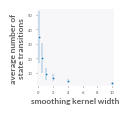

In [80]:
sigma_arr = []
sign_changes_arr = []
sign_changes_stds = []
for sigma, gdf in df_states.groupby('sigma'):
    sigma_arr.append(sigma)
    sign_changes_arr.append(np.mean([len(list(groupby(x, lambda x: x > 0))) for x in gdf['state_sequence'].values]))
    sign_changes_stds.append(np.std([len(list(groupby(x, lambda x: x > 0))) for x in gdf['state_sequence'].values]))



regseq2.viz.paper_params()
fig, ax = plt.subplots(figsize=(1, 1))
ax.set_xlabel('smoothing kernel width')
ax.set_ylabel('average number of\nstate transitions')
ax.errorbar(sigma_arr, sign_changes_arr, yerr=sign_changes_stds, marker='o', linewidth=0, markersize=2, elinewidth=.3)
fig.savefig("kernel_width_num_transitions.pdf")

In [9]:
#df_states.to_csv("hmm_results.csv", index=False)
df_states = pd.read_csv("hmm_results.csv")
df_states

,promoter,gc,rep,state_sequence
0,ihfAp4,15,2,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
1,ihfAp4,36,2,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
2,ihfAp4,14,3,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
3,ihfAp4,26,2,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
4,ihfAp4,4,3,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
...,...,...,...,...
4289,rspAp,30,2,[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0...
4290,rspAp,19,3,[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0...
4291,zapB_predicted,26,1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
4292,galSp,7,2,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...


(<Figure size 1400x200 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

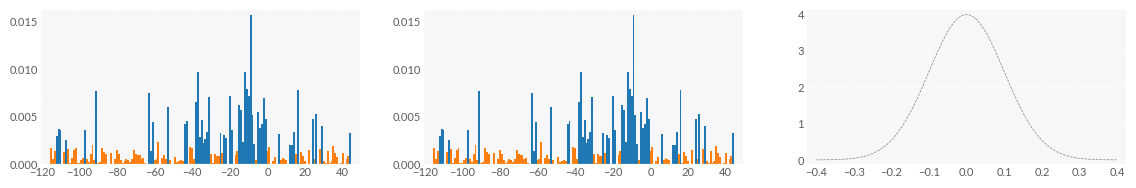

In [35]:
prom = "sulAp"
gc = 25
rep = 2

run_hmm(prom, gc, rep, sigma=0.1)

In [40]:
df = pd.read_csv(f'footprints/{gc}-{rep}_footprints.csv')
gdf = df[(df['promoter'] == prom)]
np.sum(gdf['mut_info'].values * (df_states.loc[(df_states['promoter'] == "sulAp") & (df_states['gc'] == 25) & (df_states['rep'] == 2), "state_sequence"].values[0]))/np.sum((df_states.loc[(df_states['promoter'] == "sulAp") & (df_states['gc'] == 25) & (df_states['rep'] == 2), "state_sequence"].values[0]))


    

np.float64(0.0012905346527571026)

In [6]:
def get_binding_sites(df, promoter, filter_cv=False):
    
    df_select = df.loc[df['promoter'] == promoter, :]
    df_select.sort_values("gc", inplace=True)

    if filter_cv:
        df_select = df_select.loc[df['cv'] > 0.75, :]
    
    # get wild type sequence
    wt_seq = np.array(list(df_wt.loc[df_wt['promoter'] == promoter, "promoter_seq"].values[0]))
    df_out = pd.DataFrame()
    for _, row in df_select.iterrows():
        # get replicate and growth condition
        rep = row['rep']
        gc = row['gc']

        
        
        # get expression shift matrix and compute mean per position
        df_ex = pd.read_csv(f"expression_shifts/{gc}-{rep}_exshifts.csv")
        ex_shifts = df_ex.loc[df_ex['promoter'] == promoter, :].groupby("pos")['expression_shift'].agg("mean").reset_index()

        # get binding sites
        state_seq = row['state_sequence']
        inds = np.where(state_seq == 1)[0]

        # get positions and expression shifts of binding sites
        pos = ex_shifts['pos'].values[inds]
        ex_arr = ex_shifts['expression_shift'].values[inds]
        wt_seq_bs = wt_seq[inds]
        # stop if there are no binding sites
        if np.sum(state_seq) == 0:
            break

        # iterate through binding sites
        bs = 0
        bs_arr = [0]
        for i in range(len(inds)-1):
            if (pos[i+1] - pos[i]) > 1:
                bs += 1
            bs_arr.append(bs)
        
        df_out = pd.concat([df_out, pd.DataFrame({"promoter": [promoter] * len(pos), 
                                                  "growth_condition": [gc] * len(pos), 
                                                  #"growth_condition_index": [gc_ind] * len(pos),
                                                  "replicate": [rep] * len(pos),
                                                  "pos": pos, 
                                                  "expression_shift": ex_arr, 
                                                  "binding_site": bs_arr,
                                                  "wt_base": wt_seq_bs
                                                 })])
        
    df_sum = pd.DataFrame()
    if len(df_out) == 0:
        return pd.DataFrame(), pd.DataFrame()
    gdf = df_out.groupby(["growth_condition", "binding_site", "replicate"])
    
    for (gc, bs, rep), _df in gdf:
        binding_site_sequence = "".join(_df['wt_base'].values)
        start =  np.min(_df['pos'].values)
        end = np.max(_df['pos'].values)
        
        if np.sum(_df['expression_shift'].values) > 0:
            tf_type = "repressor"
        else:
            tf_type = "activator"
        
        df_sum = pd.concat([df_sum, pd.DataFrame({"promoter": [promoter], 
                                                  "growth_condition": [gc], 
                                                  #"growth_condition_index": [gc_ind],
                                                  "replicate": [rep],
                                                  "start": [start], 
                                                  "end": [end], 
                                                  "tf_type": [tf_type],
                                                  "binding_site_sequence": [binding_site_sequence]
                                                 })])
    df_sum.sort_values(["growth_condition", "replicate"], inplace=True)
    return df_out, df_sum

In [7]:
get_binding_sites(df_states, "araBp")[1]

NameError: name 'df_states' is not defined

In [1]:
get_binding_sites(df_states, "cusCp")[1]

NameError: name 'get_binding_sites' is not defined

In [94]:
df_states[df_states['promoter'] == 'cusCp']

,promoter,gc,rep,state_sequence
1914,cusCp,30,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2630,cusCp,20,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3262,cusCp,37,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3572,cusCp,38,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3885,cusCp,38,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3899,cusCp,40,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3951,cusCp,12,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ..."


In [ ]:
prom = "tisBp"
gc = 2
rep = 1

run_hmm(prom, gc, rep, d=0, sigma=1)
run_hmm(prom, gc, rep, d=0, sigma=1.5)
run_hmm(prom, gc, rep, d=0, sigma=2)